In [1]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from wordcloud import WordCloud

import re
import string
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:

# ===============================
# 2. LOAD DATASETS
# ===============================
true_df = pd.read_csv("True.csv")
fake_df = pd.read_csv("Fake.csv")
true_df['label'] = 1   # True news
fake_df['label'] = 0   # Fake news

df = pd.concat([true_df, fake_df], axis=0)
df = df.sample(frac=1).reset_index(drop=True)  # shuffle
print(df.head())


/tmp/ipython-input-3784227940.py:5: DtypeWarning: Columns (4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171) have mixed types. Specify dtype option on import or set low_memory=False.
  fake_df = pd.read_csv("Fake.csv")


                                               title  \
0   Five States Have Now Voted To Circumvent Cong...   
1  In rare bipartisan display, Democrats back Tru...   
2  Trump administration backpedals on citizenship...   
3  Catalan protesters clash with police over 'plu...   
4  PARENTS JAILED AND KIDS TAKEN AWAY FOR 90 MINU...   

                                                text          subject  \
0  If there s one thing most progressives   both ...             News   
1  WASHINGTON (Reuters) - Three top Democratic se...     politicsNews   
2  WASHINGTON (Reuters) - A U.S. official told Co...     politicsNews   
3  BARCELONA (Reuters) - Protesters clashed with ...        worldnews   
4  This is so over the top it s not funny. I m a ...  Government News   

                 date  label Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7  \
0       June 21, 2016      0        NaN        NaN        NaN        NaN   
1     August 2, 2017       1        NaN        NaN        NaN        NaN

In [8]:
# ===============================
# 3. TEXT PREPROCESSING
# ===============================
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

df['text'] = df['text'].fillna('').apply(clean_text)

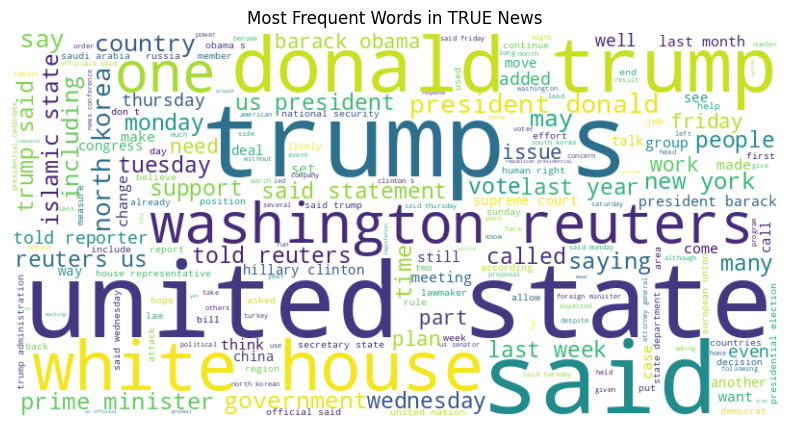

In [9]:
# ===============================
# 4. WORDCLOUD VISUALIZATION
# ===============================

# TRUE NEWS WORDCLOUD
true_text = " ".join(df[df['label'] == 1]['text'])
wc_true = WordCloud(width=800, height=400, background_color='white').generate(true_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_true, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in TRUE News")
plt.show()


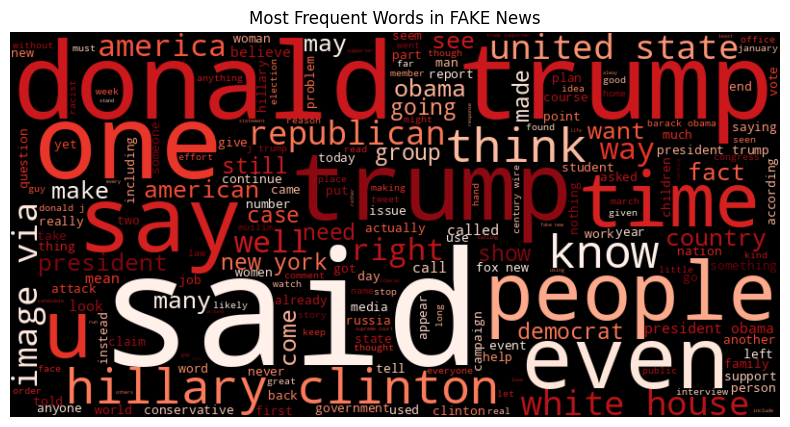

In [10]:
# FAKE NEWS WORDCLOUD
fake_text = " ".join(df[df['label'] == 0]['text'])
wc_fake = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(fake_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_fake, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in FAKE News")
plt.show()



In [11]:
# ===============================
# 5. TF-IDF FEATURE EXTRACTION
# ===============================
X = df['text']
y = df['label']

vectorizer = TfidfVectorizer(max_df=0.7)
X_tfidf = vectorizer.fit_transform(X)

In [30]:

# ===============================
# 6. TRAIN-TEST SPLIT (80-20)
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.7, random_state=42
)



In [31]:

# ===============================
# 7. LOGISTIC REGRESSION
# ===============================
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)


In [32]:
# 8. NAIVE BAYES
# ===============================
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)


In [33]:
# 9. SUPPORT VECTOR MACHINE
# ===============================
svm = LinearSVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)



In [34]:
# ===============================
# 10. FINAL RESULTS
# ===============================
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "SVM"],
    "Accuracy": [acc_lr, acc_nb, acc_svm],
    "F1 Score": [f1_lr, f1_nb, f1_svm]
})

In [35]:
print("\nMODEL PERFORMANCE COMPARISON")
print(results)


MODEL PERFORMANCE COMPARISON
                 Model  Accuracy  F1 Score
0  Logistic Regression  0.981046  0.980241
1          Naive Bayes  0.945554  0.943551
2                  SVM  0.990904  0.990526


In [36]:
# ===============================
# 11. NEWS PREDICTION (USER INPUT)
# ===============================

def predict_news(news_text, model):
    # Preprocess input news
    cleaned_news = clean_text(news_text)

    # Convert to TF-IDF
    vectorized_news = vectorizer.transform([cleaned_news])

    # Predict
    prediction = model.predict(vectorized_news)[0]

    if prediction == 1:
        return "REAL NEWS 🟢"
    else:
        return "FAKE NEWS 🔴"


In [37]:

# ===============================
# 12. USER INTERACTION
# ===============================

print("\n--- FAKE NEWS DETECTION SYSTEM ---")
user_news = input("Enter the news text to verify:\n\n")

result = predict_news(user_news, svm)   # using SVM (best model)
print("\nPrediction Result:", result)


--- FAKE NEWS DETECTION SYSTEM ---
Enter the news text to verify:

hhj

Prediction Result: FAKE NEWS 🔴


In [38]:
import joblib


In [39]:
# ===============================
# 13. SAVE MODELS & VECTORIZER
# ===============================

joblib.dump(lr, "logistic_regression_model.pkl")
joblib.dump(nb, "naive_bayes_model.pkl")
joblib.dump(svm, "svm_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Models and vectorizer saved successfully!")


Models and vectorizer saved successfully!
